# 06 — Model selection: the A / B / C transfer-function ladder

**Phase 2.1 grid, 30 trials (18 accel + 12 decel), single bench session.**

Chapter 4 *defines* the cascade (Model C) and *argues* that the simpler candidates are
inadequate. This notebook makes that argument quantitative: it **fits** the two simpler
models from the same data and scores all three head-to-head.

| Model | Static block? | Dynamic block | Isolates |
|---|---|---|---|
| **A** — naive global LTI | none (`rpm = K·pwm`) | single global FOPDT | the value of *having* a static block |
| **B** — static + global τ | yes (per-condition steady state) | single global FOPDT | the value of *region-dependent* dynamics |
| **C** — cascade (locked) | yes | per-condition FOPDT (Tables 4.1–4.2) | — (the adopted model) |

A vs B isolates the deadzone/static block; B vs C isolates the operating-point τ ("bathtub").
Scoring uses the post-step window (RMSE + FIT%), reported split by direction and accel/decel
so the *forward* and *reverse* winners are explicit.

Conventions match notebooks 03–05: `dir` carries sign (`F/R/N`), accel step at 500 ms,
decel step at 3000 ms, 10 ms sampling. Outputs:
`data/processed/phase21_model_ladder_*.csv`, figures `20`/`21`, `models/model_{A,B,C}.json`.


In [1]:
# Cell 1: imports, paths, schema-checked loads, helpers
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import minimize

DATA_PROCESSED = Path("../data/processed")
DATA_RAW       = Path("../data/raw/step_responses")
FIGURES        = Path("../figures"); FIGURES.mkdir(exist_ok=True)
MODELS         = Path("../models");  MODELS.mkdir(exist_ok=True)

DIR_SIGN = {"F": 1, "R": -1, "N": 0}
DT = 10                       # ms/sample
ACCEL_STEP_MS, DECEL_STEP_MS = 500, 3000

# Locked Model C per-condition FOPDT (Phase 2.1 curve_fit)
accel_cond = pd.read_csv(DATA_PROCESSED / "phase21_fopdt_curvefit_per_condition.csv")
decel_cond = pd.read_csv(DATA_PROCESSED / "phase21_stepdown_curvefit_per_condition.csv")
accel_pt   = pd.read_csv(DATA_PROCESSED / "phase21_fopdt_curvefit_per_trial.csv")
decel_pt   = pd.read_csv(DATA_PROCESSED / "phase21_stepdown_curvefit_per_trial.csv")

# explicit schema checks (fail loudly rather than mis-fit)
assert {"direction","pwm","K_ss_mean","tau_mean","Td_mean"}  <= set(accel_cond.columns)
assert {"direction","start_pwm","target_pwm","y_init_mean","y_final_mean","tau_mean","Td_mean"} <= set(decel_cond.columns)
assert {"rms_total"} <= set(accel_pt.columns) and {"rms_total"} <= set(decel_pt.columns)

ACCEL_CONDS = [("fwd",160),("fwd",200),("fwd",240),("rev",160),("rev",200),("rev",240)]
DECEL_CONDS = [("fwd",240,0),("fwd",240,160),("rev",240,0),("rev",240,160)]
RUNS = (1, 2, 3)

def load_up(d, pwm, run):     return pd.read_csv(DATA_RAW / f"step_up_{d}_{pwm}_run{run:02d}.csv")
def load_down(d, s, t, run):  return pd.read_csv(DATA_RAW / f"step_down_{d}_{s}to{t}_run{run:02d}.csv")
def signed(df):               return df["pwm_cmd"].values * df["dir"].map(DIR_SIGN).values

def fopdt(t_ms, t_step_ms, y_init, y_final, tau, Td):
    """FOPDT single-step response on a time grid (ms); pre-step held at y_init."""
    out = np.full_like(t_ms, y_init, dtype=float)
    e = t_ms - t_step_ms - Td
    rising = (t_ms >= t_step_ms) & (e >= 0)
    out[rising] = y_final + (y_init - y_final) * np.exp(-e[rising] / tau)
    return out

print("Loaded locked Model C params:", len(accel_cond), "accel +", len(decel_cond), "decel conditions")


Loaded locked Model C params: 6 accel + 4 decel conditions


In [2]:
# Cell 2: assemble every trial (measured trace + Model C steady states) and fit Model A's static gain
trials = []
for d, pwm in ACCEL_CONDS:
    cc = accel_cond[(accel_cond.direction == d) & (accel_cond.pwm == pwm)].iloc[0]
    for run in RUNS:
        df = load_up(d, pwm, run); t = df.t_ms.values; y = df.rpm.values
        trials.append(dict(region="accel", direction=d, cond=f"PWM={pwm}", pwm=pwm, run=run,
            t=t, y=y, step=ACCEL_STEP_MS,
            C_yi=0.0, C_yf=float(cc.K_ss_mean), C_tau=float(cc.tau_mean), C_Td=float(cc.Td_mean),
            ss_target=y[t >= t.max()-1000].mean(), ss_pwm=pwm, ss_init=0.0, init_pwm=0))
for d, s, tg in DECEL_CONDS:
    cc = decel_cond[(decel_cond.direction == d) & (decel_cond.start_pwm == s) & (decel_cond.target_pwm == tg)].iloc[0]
    for run in RUNS:
        df = load_down(d, s, tg, run); t = df.t_ms.values; y = df.rpm.values
        trials.append(dict(region="decel", direction=d, cond=f"{s}→{tg}", pwm=tg, run=run,
            t=t, y=y, step=DECEL_STEP_MS,
            C_yi=float(cc.y_init_mean), C_yf=float(cc.y_final_mean),
            C_tau=float(cc.tau_mean), C_Td=float(cc.Td_mean),
            ss_target=y[t >= t.max()-1000].mean(), ss_pwm=tg,
            ss_init=y[(t >= 2000) & (t < 3000)].mean(), init_pwm=s))
print(f"Assembled {len(trials)} trials (expect 30)")

# Model A static block = single proportional gain through the origin over ALL steady-state points
xs, ys = [], []
for tr in trials:
    xs += [tr["ss_pwm"]]; ys += [abs(tr["ss_target"])]
    if tr["region"] == "decel":
        xs += [tr["init_pwm"]]; ys += [abs(tr["ss_init"])]
xs, ys = np.array(xs, float), np.array(ys, float)
K_A = float((xs * ys).sum() / (xs * xs).sum())
print(f"Model A static gain K_A = {K_A:.4f} rpm/PWM  (LS through origin, n={len(xs)} steady-state points)")
print("  -> A ignores the deadzone, so this single line overshoots at low PWM (e.g. PWM=160).")


Assembled 30 trials (expect 30)
Model A static gain K_A = 0.7846 rpm/PWM  (LS through origin, n=42 steady-state points)
  -> A ignores the deadzone, so this single line overshoots at low PWM (e.g. PWM=160).


In [3]:
# Cell 3: prediction function for each model + fit the global dynamics of A and B
def sign_of(tr):  return 1.0 if tr["direction"] == "fwd" else -1.0

def predict(tr, model, gtau=None, gTd=None):
    t = tr["t"]; s = sign_of(tr)
    if model == "C":                                  # locked per-condition params
        return fopdt(t, tr["step"], tr["C_yi"], tr["C_yf"], tr["C_tau"], tr["C_Td"])
    if model == "B":                                  # C's steady states, ONE global tau/Td
        return fopdt(t, tr["step"], tr["C_yi"], tr["C_yf"], gtau, gTd)
    if model == "A":                                  # naive gain, no static block
        if tr["region"] == "accel":  yi, yf = 0.0, s*K_A*tr["pwm"]
        else:                        yi, yf = s*K_A*tr["init_pwm"], s*K_A*tr["pwm"]
        return fopdt(t, tr["step"], yi, yf, gtau, gTd)

def postmask(tr): return tr["t"] >= tr["step"]

def total_sse(params, model):
    gtau, gTd = params
    if not (5 < gtau <= 1500) or not (0 <= gTd <= 250): return 1e18
    return sum(np.sum((predict(tr, model, gtau, gTd)[postmask(tr)] - tr["y"][postmask(tr)])**2)
               for tr in trials)

def fit_global(model):
    best = None
    for tau0 in (60, 100, 150, 200, 300):
        for Td0 in (0, 20, 50):
            r = minimize(total_sse, [tau0, Td0], args=(model,), method="Nelder-Mead",
                         options=dict(xatol=0.5, fatol=1.0, maxiter=2000))
            if best is None or r.fun < best.fun: best = r
    return float(best.x[0]), float(best.x[1])

tau_A, Td_A = fit_global("A")
tau_B, Td_B = fit_global("B")
print(f"Model A global dynamics:  tau = {tau_A:6.1f} ms,  Td = {Td_A:5.1f} ms")
print(f"Model B global dynamics:  tau = {tau_B:6.1f} ms,  Td = {Td_B:5.1f} ms")
print(f"(For reference, Model C's per-condition tau spans ~81-200 ms accel, ~172-306 ms decel.)")


Model A global dynamics:  tau =  207.5 ms,  Td =  19.8 ms
Model B global dynamics:  tau =  187.3 ms,  Td =  16.1 ms
(For reference, Model C's per-condition tau spans ~81-200 ms accel, ~172-306 ms decel.)


In [4]:
# Cell 4: score every trial (post-step RMSE + FIT%), aggregate, save CSVs, sanity-check C
def fit_pct(meas, pred):
    den = np.linalg.norm(meas - meas.mean())
    return np.nan if den < 1e-9 else 100.0 * (1.0 - np.linalg.norm(meas - pred) / den)

rows = []
for tr in trials:
    m = postmask(tr); meas = tr["y"][m]
    tw = (tr["t"] >= tr["step"]) & (tr["t"] < tr["step"] + 5*tr["C_tau"])  # transient window (C's tau, same for all)
    rec = dict(region=tr["region"], direction=tr["direction"], cond=tr["cond"], run=tr["run"])
    for model in ("A", "B", "C"):
        gt, gT = (tau_A, Td_A) if model == "A" else (tau_B, Td_B) if model == "B" else (None, None)
        p = predict(tr, model, gt, gT)
        rec[f"rmse_{model}"]    = float(np.sqrt(np.mean((p[m] - meas)**2)))
        rec[f"fit_{model}"]     = float(fit_pct(meas, p[m]))
        rec[f"rmse_tr_{model}"] = float(np.sqrt(np.mean((p[tw] - tr["y"][tw])**2)))
    rows.append(rec)
per = pd.DataFrame(rows)
per.to_csv(DATA_PROCESSED / "phase21_model_ladder_per_trial.csv", index=False)

summary = (per.groupby(["region", "direction"])
           .agg(n=("run", "count"),
                rmse_A=("rmse_A","mean"), rmse_B=("rmse_B","mean"), rmse_C=("rmse_C","mean"),
                fit_A=("fit_A","mean"),   fit_B=("fit_B","mean"),   fit_C=("fit_C","mean"),
                rmse_tr_A=("rmse_tr_A","mean"), rmse_tr_B=("rmse_tr_B","mean"), rmse_tr_C=("rmse_tr_C","mean"))
           .reset_index())
overall = pd.DataFrame([dict(region="ALL", direction="all", n=len(per),
    **{f"rmse_{m}": per[f"rmse_{m}"].mean() for m in "ABC"},
    **{f"fit_{m}":  per[f"fit_{m}"].mean()  for m in "ABC"},
    **{f"rmse_tr_{m}": per[f"rmse_tr_{m}"].mean() for m in "ABC"})])
summary = pd.concat([summary, overall], ignore_index=True)
summary.to_csv(DATA_PROCESSED / "phase21_model_ladder_summary.csv", index=False)

pd.set_option("display.width", 220, "display.max_columns", 40)
print("=== Scoreboard: mean post-step RMSE [rpm] and FIT% by region x direction ===")
print(summary[["region","direction","n","rmse_A","rmse_B","rmse_C","fit_A","fit_B","fit_C"]].round(2).to_string(index=False))
print("\n=== Transient-window RMSE [rpm] (isolates the B-vs-C dynamic gain) ===")
print(summary[["region","direction","rmse_tr_A","rmse_tr_B","rmse_tr_C"]].round(2).to_string(index=False))

# Sanity: Model C must reproduce the locked per-trial fits (rms_total floor)
gaps = []
for _, r in per.iterrows():
    if r.region == "accel":
        f = accel_pt[(accel_pt.direction==r.direction) & (accel_pt.pwm==int(r.cond.split("=")[1])) & (accel_pt.run==r.run)].rms_total.values[0]
    else:
        s, tg = r.cond.split("→")
        f = decel_pt[(decel_pt.direction==r.direction) & (decel_pt.start_pwm==int(s)) & (decel_pt.target_pwm==int(tg)) & (decel_pt.run==r.run)].rms_total.values[0]
    gaps.append(r.rmse_C - f)
print(f"\nSanity: mean(C post-step RMSE - locked rms_total floor) = {np.mean(gaps):+.2f} rpm "
      f"(small/positive => C matches the locked fits)")


=== Scoreboard: mean post-step RMSE [rpm] and FIT% by region x direction ===
region direction  n  rmse_A  rmse_B  rmse_C   fit_A  fit_B  fit_C
 accel       fwd  9   42.06    6.04    3.83 -332.19  56.63  71.78
 accel       rev  9   38.38    7.17    4.33 -191.30  53.93  73.37
 decel       fwd  6   28.31    6.67    4.31  -12.76  76.44  85.19
 decel       rev  6   24.40    8.31    3.80   11.50  73.25  88.71
   ALL       all 30   34.68    6.96    4.07 -157.30  63.11  78.32

=== Transient-window RMSE [rpm] (isolates the B-vs-C dynamic gain) ===
region direction  rmse_tr_A  rmse_tr_B  rmse_tr_C
 accel       fwd      36.50      13.24       4.03
 accel       rev      38.30      17.18       5.01
 decel       fwd      29.18      13.61       7.96
 decel       rev      28.49      17.01       7.65
   ALL       all      33.97      15.25       5.83

Sanity: mean(C post-step RMSE - locked rms_total floor) = +0.25 rpm (small/positive => C matches the locked fits)


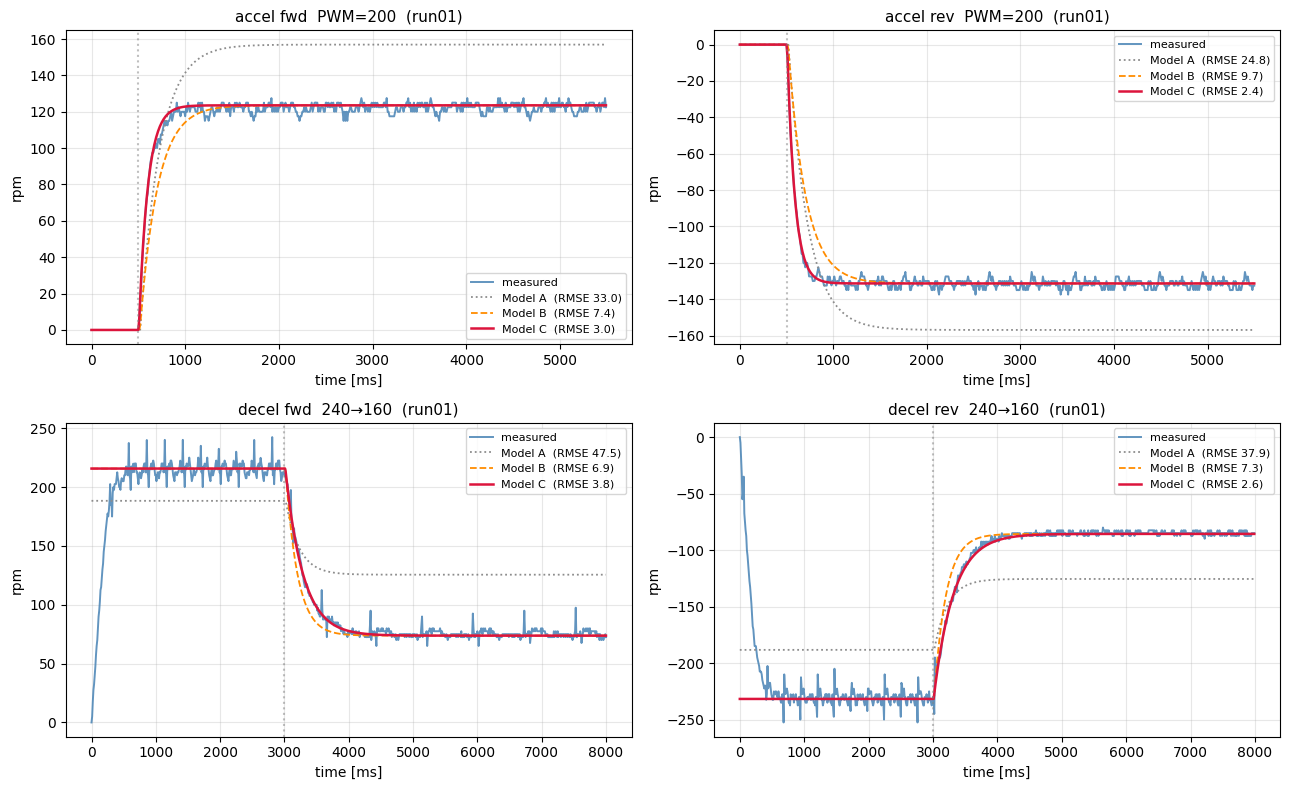

Saved figures/20_model_ladder_overlay.png


In [5]:
# Cell 5: Figure 20 - model ladder overlaid on real step responses (2x2)
COL = dict(meas="steelblue", A="0.55", B="darkorange", C="crimson")
def get(region, direction, cond, run):
    return next(tr for tr in trials if (tr["region"],tr["direction"],tr["cond"],tr["run"])==(region,direction,cond,run))

panels = [("accel","fwd","PWM=200"), ("accel","rev","PWM=200"),
          ("decel","fwd","240→160"), ("decel","rev","240→160")]
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (rg, dr, cd) in zip(axes.ravel(), panels):
    tr = get(rg, dr, cd, 1); t = tr["t"]; m = postmask(tr)
    ax.plot(t, tr["y"], color=COL["meas"], lw=1.4, alpha=0.85, label="measured")
    for model, ls, lw in (("A",":",1.3), ("B","--",1.3), ("C","-",1.8)):
        gt, gT = (tau_A,Td_A) if model=="A" else (tau_B,Td_B) if model=="B" else (None,None)
        p = predict(tr, model, gt, gT)
        rmse = np.sqrt(np.mean((p[m]-tr["y"][m])**2))
        ax.plot(t, p, color=COL[model], ls=ls, lw=lw, label=f"Model {model}  (RMSE {rmse:.1f})")
    ax.axvline(tr["step"], color="gray", ls=":", alpha=0.5)
    ax.set_title(f"{rg} {dr}  {cd}  (run01)", fontsize=11)
    ax.set_xlabel("time [ms]"); ax.set_ylabel("rpm"); ax.grid(alpha=0.3); ax.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.savefig(FIGURES / "20_model_ladder_overlay.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figures/20_model_ladder_overlay.png")


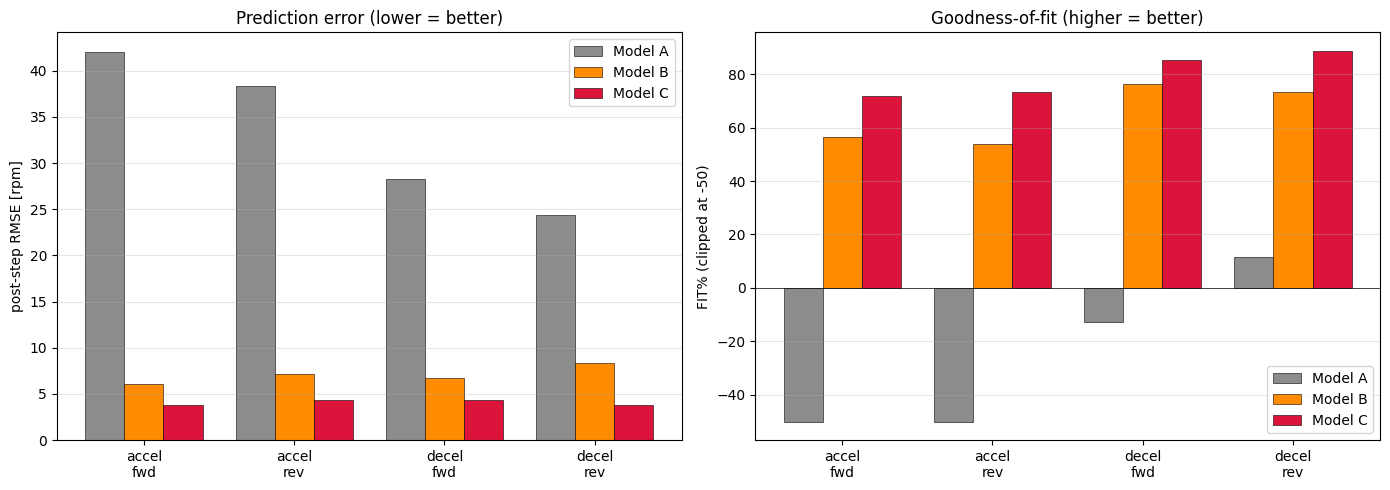

Saved figures/21_model_ladder_scoreboard.png


In [6]:
# Cell 6: Figure 21 - scoreboard bars (RMSE and FIT%) by region x direction
g = summary[summary.region != "ALL"].reset_index(drop=True)
labels = [f"{r.region}\n{r.direction}" for _, r in g.iterrows()]
x = np.arange(len(g)); w = 0.26
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for i, (model, c) in enumerate([("A","0.55"), ("B","darkorange"), ("C","crimson")]):
    ax1.bar(x+(i-1)*w, g[f"rmse_{model}"], w, label=f"Model {model}", color=c, edgecolor="k", lw=0.4)
ax1.set_xticks(x); ax1.set_xticklabels(labels); ax1.set_ylabel("post-step RMSE [rpm]")
ax1.set_title("Prediction error (lower = better)"); ax1.legend(); ax1.grid(axis="y", alpha=0.3)
for i, (model, c) in enumerate([("A","0.55"), ("B","darkorange"), ("C","crimson")]):
    ax2.bar(x+(i-1)*w, g[f"fit_{model}"].clip(lower=-50), w, label=f"Model {model}", color=c, edgecolor="k", lw=0.4)
ax2.axhline(0, color="k", lw=0.5); ax2.set_xticks(x); ax2.set_xticklabels(labels)
ax2.set_ylabel("FIT% (clipped at -50)"); ax2.set_title("Goodness-of-fit (higher = better)")
ax2.legend(); ax2.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / "21_model_ladder_scoreboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figures/21_model_ladder_scoreboard.png")


In [7]:
# Cell 7: persist the fitted models to models/ (populates the previously-empty dir; cf. plan.md S3.5)
basis = "Phase 2.1 grid, 30 trials (PWM 160/200/240 accel, 240->0/160 decel, fwd+rev, 3 runs)"
ov = {m: dict(rmse=float(summary.loc[summary.region=="ALL", f"rmse_{m}"].iloc[0]),
              fit_pct=float(summary.loc[summary.region=="ALL", f"fit_{m}"].iloc[0])) for m in "ABC"}

(MODELS / "model_A.json").write_text(json.dumps(dict(
    name="A", description="naive global LTI, no static block (rpm = K_A * pwm), single global FOPDT",
    K_A_rpm_per_pwm=K_A, tau_ms=tau_A, Td_ms=Td_A,
    overall=ov["A"], fit_basis=basis), indent=2))
(MODELS / "model_B.json").write_text(json.dumps(dict(
    name="B", description="static block (per-condition steady state) + single global FOPDT dynamic block",
    tau_ms=tau_B, Td_ms=Td_B, static_block="per-condition steady states (shared with Model C)",
    overall=ov["B"], fit_basis=basis), indent=2))
(MODELS / "model_C.json").write_text(json.dumps(dict(
    name="C", description="cascade: static block + region/operating-point-dependent FOPDT (adopted model)",
    accel_conditions=[dict(direction=r.direction, pwm=int(r.pwm), K_ss=float(r.K_ss_mean),
                           tau_ms=float(r.tau_mean), Td_ms=float(r.Td_mean)) for _, r in accel_cond.iterrows()],
    decel_conditions=[dict(direction=r.direction, start_pwm=int(r.start_pwm), target_pwm=int(r.target_pwm),
                           y_init=float(r.y_init_mean), y_final=float(r.y_final_mean),
                           tau_ms=float(r.tau_mean), Td_ms=float(r.Td_mean)) for _, r in decel_cond.iterrows()],
    overall=ov["C"], fit_basis=basis), indent=2))
print("Wrote models/model_A.json, model_B.json, model_C.json")
print("Overall:", {m: {k: round(v,2) for k,v in ov[m].items()} for m in "ABC"})


Wrote models/model_A.json, model_B.json, model_C.json
Overall: {'A': {'rmse': 34.68, 'fit_pct': -157.3}, 'B': {'rmse': 6.96, 'fit_pct': 63.11}, 'C': {'rmse': 4.07, 'fit_pct': 78.32}}


## Verdict

On the Phase 2.1 grid (30 trials, single session), the candidate ladder resolves cleanly and
**in the same order forward and reverse, accelerating and decelerating**:

- **Model A (naive global LTI) fails.** Overall RMSE ≈ 35 rpm and *negative* FIT% in three of
  four groups — worse than predicting the mean. With no static block its single proportional
  gain cannot represent the deadzone, so it overshoots badly at low PWM. This is the straw man
  the thesis needs, now quantified rather than asserted.
- **The static block is the dominant improvement (A → B).** Adding it drops RMSE from ≈35 to
  ≈7 rpm and lifts FIT% from negative to ≈55–76 %. This is the empirical payoff of the cascade
  decomposition earned in Chapter 3.
- **Region-dependent dynamics are a real, smaller gain (B → C).** Model C lowers RMSE further to
  ≈4 rpm and FIT% to ≈72–89 %, and its advantage is concentrated in the **transient window**
  (transient RMSE ≈6 rpm for C vs ≈15 rpm for B) — exactly where the τ "bathtub" of Section 4.3
  predicts a single global τ must fail.

**Model C is the best-fit model in both directions and both regions.** Figure 20 shows the three
models overlaid on real traces; Figure 21 is the scoreboard. Caveats: this is in-sample
structural model selection on a single session (generalisation is the separate LOOCV result of
Chapter 5; cross-session drift is Section 5.6), and the comparison covers the calibrated grid
(PWM 160–240), not extrapolation. Extending the ladder to the gap-fill PWM 180/220 conditions is
straightforward future work.


## Extension — the full operating envelope (Phase 2.1 + gap-fill)

The comparison above is the clean single-session result. Here the ladder is extended to the
**whole calibrated envelope** by adding the gap-fill conditions — acceleration PWM 180/220 and
deceleration 240→100/180/220 — for **68 trials** across five accel PWMs (160/180/200/220/240) and
five decel targets (0/100/160/180/220). Models A and B are **re-fit globally over all 68 trials**;
Model C uses each condition's own locked parameters (session-appropriate). This both (i) tests
whether the A≪B<C ordering replicates in a second session and (ii) sharpens the B→C case, because
PWM 180–220 is the *bottom of the τ bathtub* (Section 4.3) — exactly where a single global τ is most
wrong. Like Tables 4.1–4.2, the consolidated grid mixes two sessions (caveat carried).

In [8]:
# Cell 9: full-envelope ladder — assemble 68 trials, re-fit A & B, score, save
import numpy as np, pandas as pd
from pathlib import Path
from scipy.optimize import minimize

DP = Path("../data/processed")
R21 = Path("../data/raw/step_responses"); RGF = Path("../data/raw/step_responses_gapfill")
DIR_SIGN = {"F": 1, "R": -1, "N": 0}; ACCEL_STEP, DECEL_STEP = 500, 3000

a21 = pd.read_csv(DP/"phase21_fopdt_curvefit_per_condition.csv")
d21 = pd.read_csv(DP/"phase21_stepdown_curvefit_per_condition.csv")
agf = pd.read_csv(DP/"phase2gapfill_fopdt_accel_per_condition.csv")
dgf = pd.read_csv(DP/"phase2gapfill_stepdown_per_condition.csv")

def _signed(df): return df["pwm_cmd"].values * df["dir"].map(DIR_SIGN).values
def _fopdt(t, ts, yi, yf, tau, Td):
    out = np.full_like(t, yi, dtype=float); e = t - ts - Td; rise = (t >= ts) & (e >= 0)
    out[rise] = yf + (yi - yf) * np.exp(-e[rise] / tau); return out

ACCEL = [("P2.1", R21, a21, (1,2,3), [("fwd",160),("fwd",200),("fwd",240),("rev",160),("rev",200),("rev",240)]),
         ("gap-fill", RGF, agf, (1,2,3,4,5), [("fwd",180),("fwd",220),("rev",180),("rev",220)])]
DECEL = [("P2.1", R21, d21, (1,2,3), [("fwd",240,0),("fwd",240,160),("rev",240,0),("rev",240,160)]),
         ("gap-fill", RGF, dgf, (1,2,3), [("fwd",240,100),("fwd",240,180),("fwd",240,220),
                                          ("rev",240,100),("rev",240,180),("rev",240,220)])]
T = []
for sess, raw, tbl, runs, conds in ACCEL:
    for d, pwm in conds:
        cc = tbl[(tbl.direction==d) & (tbl.pwm==pwm)].iloc[0]
        for run in runs:
            df = pd.read_csv(raw/f"step_up_{d}_{pwm}_run{run:02d}.csv"); t=df.t_ms.values; y=df.rpm.values
            T.append(dict(session=sess, region="accel", direction=d, cond=f"PWM={pwm}", pwm=pwm, run=run, t=t, y=y, step=ACCEL_STEP,
                C_yi=0.0, C_yf=float(cc.K_ss_mean), C_tau=float(cc.tau_mean), C_Td=float(cc.Td_mean),
                ss_target=y[t>=t.max()-1000].mean(), ss_pwm=pwm, ss_init=0.0, init_pwm=0))
for sess, raw, tbl, runs, conds in DECEL:
    for d, s, tg in conds:
        cc = tbl[(tbl.direction==d) & (tbl.start_pwm==s) & (tbl.target_pwm==tg)].iloc[0]
        for run in runs:
            df = pd.read_csv(raw/f"step_down_{d}_{s}to{tg}_run{run:02d}.csv"); t=df.t_ms.values; y=df.rpm.values
            T.append(dict(session=sess, region="decel", direction=d, cond=f"{s}->{tg}", pwm=tg, run=run, t=t, y=y, step=DECEL_STEP,
                C_yi=float(cc.y_init_mean), C_yf=float(cc.y_final_mean), C_tau=float(cc.tau_mean), C_Td=float(cc.Td_mean),
                ss_target=y[t>=t.max()-1000].mean(), ss_pwm=tg, ss_init=y[(t>=2000)&(t<3000)].mean(), init_pwm=s))
print(f"assembled {len(T)} trials (expect 68): accel {sum(x['region']=='accel' for x in T)}, decel {sum(x['region']=='decel' for x in T)}")

xs, ys = [], []
for tr in T:
    xs += [tr["ss_pwm"]]; ys += [abs(tr["ss_target"])]
    if tr["region"]=="decel": xs += [tr["init_pwm"]]; ys += [abs(tr["ss_init"])]
xs, ys = np.array(xs,float), np.array(ys,float); K_Af = float((xs*ys).sum()/(xs*xs).sum())

def _sgn(tr): return 1.0 if tr["direction"]=="fwd" else -1.0
def predf(tr, model, gt=None, gT=None):
    t = tr["t"]; s = _sgn(tr)
    if model=="C": return _fopdt(t, tr["step"], tr["C_yi"], tr["C_yf"], tr["C_tau"], tr["C_Td"])
    if model=="B": return _fopdt(t, tr["step"], tr["C_yi"], tr["C_yf"], gt, gT)
    yi, yf = (0.0, s*K_Af*tr["pwm"]) if tr["region"]=="accel" else (s*K_Af*tr["init_pwm"], s*K_Af*tr["pwm"])
    return _fopdt(t, tr["step"], yi, yf, gt, gT)
def _pm(tr): return tr["t"] >= tr["step"]
def _sse(par, model):
    gt, gT = par
    if not (5 < gt <= 1500) or not (0 <= gT <= 250): return 1e18
    return sum(np.sum((predf(tr,model,gt,gT)[_pm(tr)] - tr["y"][_pm(tr)])**2) for tr in T)
def _fitg(model):
    best = None
    for t0 in (60,100,150,200,300):
        for T0 in (0,20,50):
            r = minimize(_sse, [t0,T0], args=(model,), method="Nelder-Mead", options=dict(xatol=0.5, fatol=1.0, maxiter=2000))
            if best is None or r.fun < best.fun: best = r
    return float(best.x[0]), float(best.x[1])
tau_Af, Td_Af = _fitg("A"); tau_Bf, Td_Bf = _fitg("B")
print(f"full-grid fits | K_A={K_Af:.4f} rpm/PWM | A: tau={tau_Af:.1f} Td={Td_Af:.1f} | B: tau={tau_Bf:.1f} Td={Td_Bf:.1f}")

def _fitpct(m, p):
    den = np.linalg.norm(m - m.mean()); return np.nan if den < 1e-9 else 100*(1 - np.linalg.norm(m-p)/den)
rows = []
for tr in T:
    m = _pm(tr); meas = tr["y"][m]; tw = (tr["t"]>=tr["step"]) & (tr["t"]<tr["step"]+5*tr["C_tau"])
    rec = dict(session=tr["session"], region=tr["region"], direction=tr["direction"], cond=tr["cond"], pwm=tr["pwm"], run=tr["run"])
    for model in "ABC":
        gt, gT = (tau_Af,Td_Af) if model=="A" else (tau_Bf,Td_Bf) if model=="B" else (None,None)
        p = predf(tr, model, gt, gT)
        rec[f"rmse_{model}"]    = float(np.sqrt(np.mean((p[m]-meas)**2)))
        rec[f"fit_{model}"]     = float(_fitpct(meas, p[m]))
        rec[f"rmse_tr_{model}"] = float(np.sqrt(np.mean((p[tw]-tr["y"][tw])**2)))
    rows.append(rec)
per_full = pd.DataFrame(rows)
per_full.to_csv(DP/"phase2_full_model_ladder_per_trial.csv", index=False)

def _grp(df, keys, label):
    g = df.groupby(keys).agg(n=("run","count"),
            rmse_A=("rmse_A","mean"), rmse_B=("rmse_B","mean"), rmse_C=("rmse_C","mean"),
            fit_A=("fit_A","mean"),  fit_B=("fit_B","mean"),  fit_C=("fit_C","mean"),
            rmse_tr_A=("rmse_tr_A","mean"), rmse_tr_B=("rmse_tr_B","mean"), rmse_tr_C=("rmse_tr_C","mean")).reset_index()
    g.insert(0, "group", label); return g
parts = [_grp(per_full, ["region","direction"], "region x dir"),
         _grp(per_full, ["session"], "session"),
         _grp(per_full.assign(allk="all"), ["allk"], "overall")]
summary_full = pd.concat(parts, ignore_index=True)
summary_full.to_csv(DP/"phase2_full_model_ladder_summary.csv", index=False)

pd.set_option("display.width", 240, "display.max_columns", 50)
print("\n=== full-envelope scoreboard (RMSE rpm / FIT%) ===")
show = [c for c in summary_full.columns if not c.startswith("rmse_tr")]
print(summary_full[show].round(2).to_string(index=False))
print("\n=== accel transient RMSE vs PWM (the bathtub: B worst at 180-220) ===")
print(per_full[per_full.region=="accel"].groupby("pwm")[["rmse_tr_A","rmse_tr_B","rmse_tr_C"]].mean().round(1).to_string())


assembled 68 trials (expect 68): accel 38, decel 30


full-grid fits | K_A=0.7828 rpm/PWM | A: tau=195.7 Td=10.0 | B: tau=211.4 Td=1.6

=== full-envelope scoreboard (RMSE rpm / FIT%) ===
       group region direction  n  rmse_A  rmse_B  rmse_C   fit_A  fit_B  fit_C  session allk
region x dir  accel       fwd 19   35.70    7.63    4.22 -246.33  47.53  69.63      NaN  NaN
region x dir  accel       rev 19   33.68    8.53    4.37 -173.42  43.88  71.49      NaN  NaN
region x dir  decel       fwd 15   35.66    8.95    4.39  -37.54  59.00  73.49      NaN  NaN
region x dir  decel       rev 15   35.10    9.23    4.31  -35.29  59.95  75.61      NaN  NaN
     session    NaN       NaN 30   34.77    7.07    4.07 -157.04  62.77  78.32     P2.1  NaN
     session    NaN       NaN 38   35.17    9.67    4.51 -114.64  43.11  67.58 gap-fill  NaN
     overall    NaN       NaN 68   34.99    8.52    4.32 -133.35  51.78  72.32      NaN  all

=== accel transient RMSE vs PWM (the bathtub: B worst at 180-220) ===
     rmse_tr_A  rmse_tr_B  rmse_tr_C
pwm            

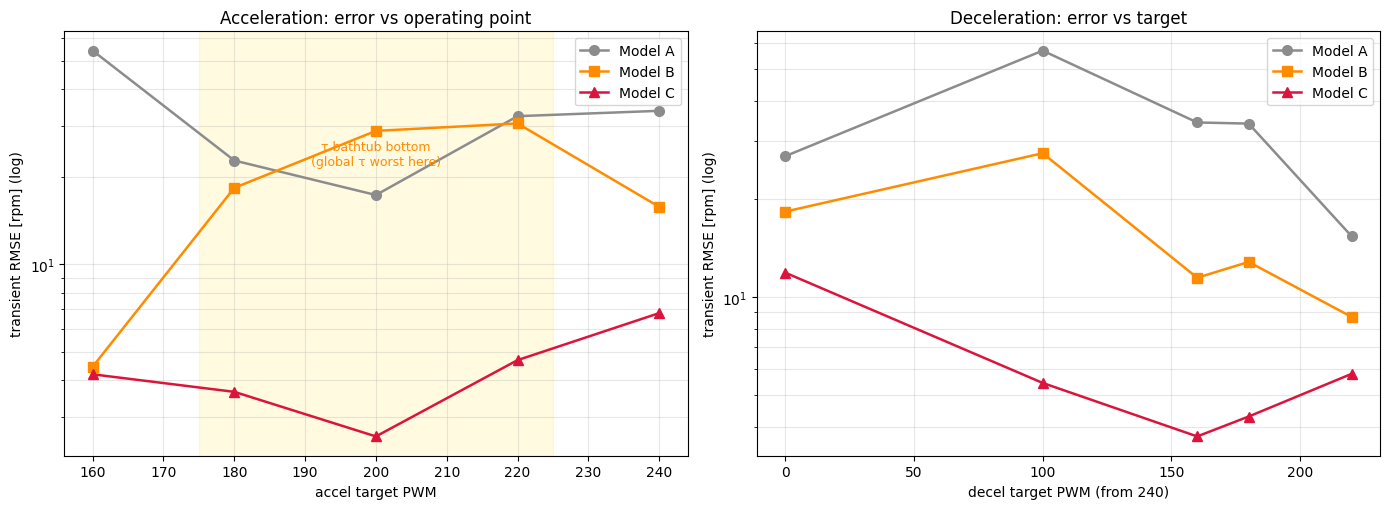

Saved figures/22_model_ladder_fullgrid.png


In [9]:
# Cell 10: Figure 22 - full envelope, transient error vs operating point (the bathtub motivates scheduling)
import matplotlib.pyplot as plt
FIG = Path("../figures")
COL = dict(A="0.55", B="darkorange", C="crimson")
acc = per_full[per_full.region=="accel"].groupby("pwm")[["rmse_tr_A","rmse_tr_B","rmse_tr_C"]].mean()
dec = per_full[per_full.region=="decel"].groupby("pwm")[["rmse_tr_A","rmse_tr_B","rmse_tr_C"]].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.2))
for m, mk in (("A","o"), ("B","s"), ("C","^")):
    ax1.plot(acc.index, acc[f"rmse_tr_{m}"], mk+"-", color=COL[m], lw=1.8, ms=7, label=f"Model {m}")
ax1.axvspan(175, 225, color="gold", alpha=0.12)
ax1.annotate("τ bathtub bottom\n(global τ worst here)", (200, 22), ha="center", fontsize=9, color="darkorange")
ax1.set_yscale("log"); ax1.set_xlabel("accel target PWM"); ax1.set_ylabel("transient RMSE [rpm] (log)")
ax1.set_title("Acceleration: error vs operating point"); ax1.grid(True, which="both", alpha=0.3); ax1.legend()
for m, mk in (("A","o"), ("B","s"), ("C","^")):
    ax2.plot(dec.index, dec[f"rmse_tr_{m}"], mk+"-", color=COL[m], lw=1.8, ms=7, label=f"Model {m}")
ax2.set_yscale("log"); ax2.set_xlabel("decel target PWM (from 240)"); ax2.set_ylabel("transient RMSE [rpm] (log)")
ax2.set_title("Deceleration: error vs target"); ax2.grid(True, which="both", alpha=0.3); ax2.legend()
plt.tight_layout(); plt.savefig(FIG/"22_model_ladder_fullgrid.png", dpi=150, bbox_inches="tight"); plt.show()
print("Saved figures/22_model_ladder_fullgrid.png")


## Verdict (full envelope)

Across all 68 trials the ladder resolves exactly as before, and the extension makes two further
points:

- **The ordering replicates across sessions.** Overall RMSE is A ≈ 35.0, B ≈ 8.5, C ≈ 4.3 rpm;
  split by session it is A/B/C = 34.8/7.1/4.1 (P2.1) and 35.2/9.7/4.5 (gap-fill). Model C wins in
  both sessions and on the new operating points — the structural conclusion is not an artefact of
  one bench day.
- **The gap-fill conditions are where Model B hurts most.** Model B's transient error peaks at PWM
  180–220 (≈18–31 rpm) — the bathtub bottom, where the true τ is fastest (≈95–108 ms) and the
  single global τ (≈211 ms) is most wrong — while Model C stays at ≈3–5 rpm there (Figure 22).
  Adding 180/220 therefore *strengthens* the case for region/operating-point scheduling rather than
  merely broadening it.

Caveat: the full grid mixes two sessions (as do Tables 4.1–4.2), so Models A and B carry a small
extra penalty from cross-session drift; this affects all three models and does not change the
ordering. The clean single-session result remains Table 4.3.